# Logjam v0.2.2 — Helper Function Verification

This notebook exercises all new helper functions introduced in v0.2.2:

| # | Function | Module | Purpose |
|---|----------|--------|---------|
| H1 | `mat2df` | Core | Matrix → labeled DataFrame |
| H2 | `prt` | Core | Formatted matrix/vector/DataFrame display |
| H3 | `snapvals` | Core | Snap near-integer/near-zero floats |
| H4 | `dcf` | CairoMakie ext | Display current figure |
| H5 | `plotnetwork` | CairoMakie ext | Network diagram from cost matrix |

Each section runs multiple usage variants. If every cell completes without error and the outputs look correct, the helpers are working.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

  Activating project at `c:\Users\kay\Documents\cdev\log\Logjam`


In [2]:
using Logjam
using CairoMakie
using DataFrames

---
## H1: `mat2df` — Matrix to DataFrame

In [4]:
# Basic: 3×2 matrix with column names
M = [10 20; 30 40; 50 60]
df = mat2df(M, ["Cost", "Demand"])
display(df)

Row,Cost,Demand
,Int64,Int64
1,10,20
2,30,40
3,50,60


In [5]:
# With row labels: warehouse-to-customer cost matrix
C = [12.5 8.3 15.0; 9.1 14.2 7.8]
df = mat2df(C, ["Cust1", "Cust2", "Cust3"]; rows=["WH-Atlanta", "WH-Dallas"])
display(df)

Row,,Cust1,Cust2,Cust3
,String,Float64,Float64,Float64
1,WH-Atlanta,12.5,8.3,15.0
2,WH-Dallas,9.1,14.2,7.8


In [6]:
# Single-element matrix
df = mat2df(reshape([42], 1, 1), ["Value"])
display(df)

Row,Value
,Int64
1,42


In [7]:
# Error case: mismatched column count
try
    mat2df([1 2; 3 4], ["A"])
catch e
    println("Expected error: ", e)
end

Expected error: ArgumentError("length(cols) = 1 must equal size(X, 2) = 2")


---
## H2: `prt` — Formatted Display

In [8]:
# Integer matrix — 0 decimal places, comma separators
prt([1500 2300; 4100 800])

 ─── ─────── ───────
          1       2 
 ─── ─────── ───────
  1   1,500   2,300
  2   4,100     800
 ─── ─────── ───────


In [10]:
# Fractional matrix (all values < 1) — 4 decimal places
prt([0.1234234 0.56; 0.9023423412 0.323423456])

 ─── ──────── ────────
           1        2 
 ─── ──────── ────────
  1   0.1234   0.5600
  2   0.9023   0.3234
 ─── ──────── ────────


In [16]:
# Mixed matrix — 2 decimal places, commas for ≥1000
prt([1 2000.75824; 3 4500.25])

 ─── ─── ───────
      1       2 
 ─── ─── ───────
  1   1   2,001
  2   3   4,500
 ─── ─── ───────


In [17]:
# Custom row/column labels + row_title
D = [0 165 25; 165 0 140; 25 140 0]
prt(D; rows=["Raleigh", "Charlotte", "Durham"],
       cols=["Raleigh", "Charlotte", "Durham"],
       row_title="City")

 ─────────── ───────── ─────────── ────────
       City   Raleigh   Charlotte   Durham 
 ─────────── ───────── ─────────── ────────
    Raleigh         0         165       25
  Charlotte       165           0      140
     Durham        25         140        0
 ─────────── ───────── ─────────── ────────


In [18]:
# NaN handling — NaN displays as blank
prt([1.0 NaN 3.0; NaN 5.0 6.0]; cols=["A", "B", "C"])

 ─── ─── ─── ───
      A   B   C 
 ─── ─── ─── ───
  1   1       3
  2       5   6
 ─── ─── ─── ───


In [19]:
# Vector method — single column with row indices
prt([100, 250, 375]; rows=["Q1", "Q2", "Q3"], row_title="Quarter")

 ───────── ─────
  Quarter       
 ───────── ─────
       Q1   100
       Q2   250
       Q3   375
 ───────── ─────


In [20]:
# DataFrame method
df = DataFrame(City=["Raleigh", "Charlotte", "Durham"], Pop=[467665, 874579, 283506])
prt(df)

 ─────────── ────────
       City      Pop 
 ─────────── ────────
    Raleigh   467665
  Charlotte   874579
     Durham   283506
 ─────────── ────────


In [21]:
# Title keyword
prt([1 2; 3 4]; title="Sample Matrix")

Sample Matrix
 ─── ─── ───
      1   2 
 ─── ─── ───
  1   1   2
  2   3   4
 ─── ─── ───


In [22]:
# Empty matrix — should print "Empty matrix" without error
prt(Matrix{Float64}(undef, 0, 0))

Empty matrix


In [23]:
# Wide matrix — verify no column cropping
prt(rand(3, 12); cols=string.('A':'L'))

 ─── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ────────
           A        B        C        D        E        F        G        H        I        J        K        L 
 ─── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ────────
  1   0.9219   0.2344   0.9027   0.5954   0.3197   0.1237   0.4981   0.7732   0.3577   0.5449   0.2347   0.1203
  2   0.7515   0.1733   0.2113   0.4312   0.0046   0.8503   0.9074   0.2598   0.8065   0.2898   0.7090   0.7978
  3   0.9039   0.5973   0.3296   0.5387   0.5391   0.9942   0.3134   0.9882   0.5420   0.2204   0.2578   0.0605
 ─── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ──────── ────────


---
## H3: `snapvals` — Snap Near-Integer/Near-Zero Values

In [24]:
# Near-integer snapping (typical solver output)
x = [2.9999999997, 1.0000000003, 0.5]
result = snapvals(x)
println("Input:  ", x)
println("Snapped:", result)
@assert result ≈ [3.0, 1.0, 0.5]

Input:  [2.9999999997, 1.0000000003, 0.5]
Snapped:[3.0, 1.0, 0.5]


In [25]:
# Near-zero snapping
x = [1e-12, -1e-12, 0.5, 1.0]
result = snapvals(x)
println("Input:  ", x)
println("Snapped:", result)
@assert result ≈ [0.0, 0.0, 0.5, 1.0]

Input:  [1.0e-12, -1.0e-12, 0.5, 1.0]
Snapped:[0.0, 0.0, 0.5, 1.0]


In [26]:
# Reshape variant: flat vector → matrix
x = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
M = snapvals(x, 2, 3)
println("Reshaped $(length(x))-vector to $(size(M)) matrix:")
display(M)

Reshaped 6-vector to (2, 3) matrix:


2×3 Matrix{Float64}:
 1.0  3.0  5.0
 2.0  4.0  6.0

In [27]:
# Custom tolerance
result = snapvals([1.1, 2.05, 3.3]; atol=0.2)
println("atol=0.2: ", result)
@assert result ≈ [1.0, 2.0, 3.3]  # 3.3 is too far from 3

atol=0.2: [1.0, 2.0, 3.3]


In [28]:
# Values far from integers — unchanged
x = [1.3, 2.7, 0.5]
result = snapvals(x)
@assert result == x
println("Far from integers: unchanged ✓")

# Empty array
result = snapvals(Float64[])
@assert isempty(result)
println("Empty array:       unchanged ✓")

Far from integers: unchanged ✓
Empty array:       unchanged ✓


---
## H4: `dcf` — Display Current Figure


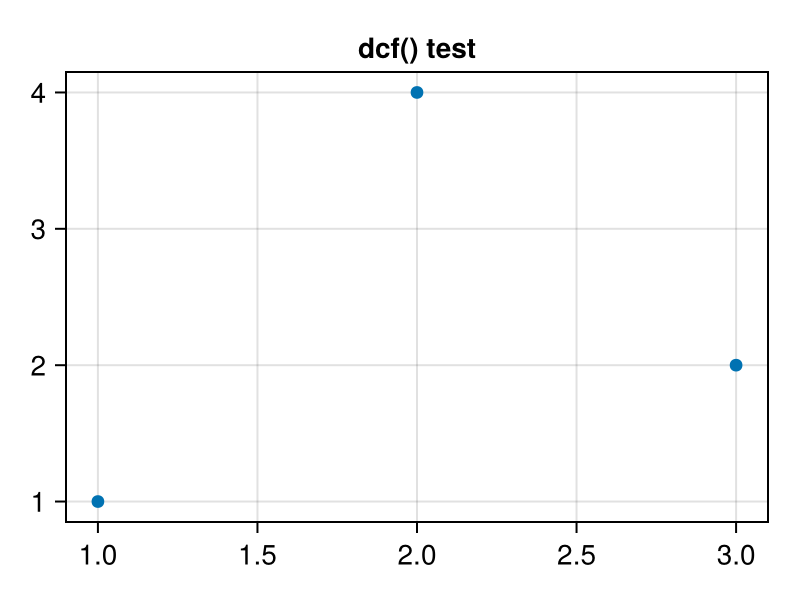

In [37]:
# Create a simple figure and display it with dcf()
fig = Figure(size=(400, 300))
ax = Axis(fig[1,1], title="dcf() test")
scatter!(ax, [1,2,3], [1,4,2])
dcf()

---
## H5: `plotnetwork` — Network Visualization


Node positions:


4×2 Matrix{Float64}:
  1.0           0.0
  6.12323e-17   1.0
 -1.0           1.22465e-16
 -1.83697e-16  -1.0

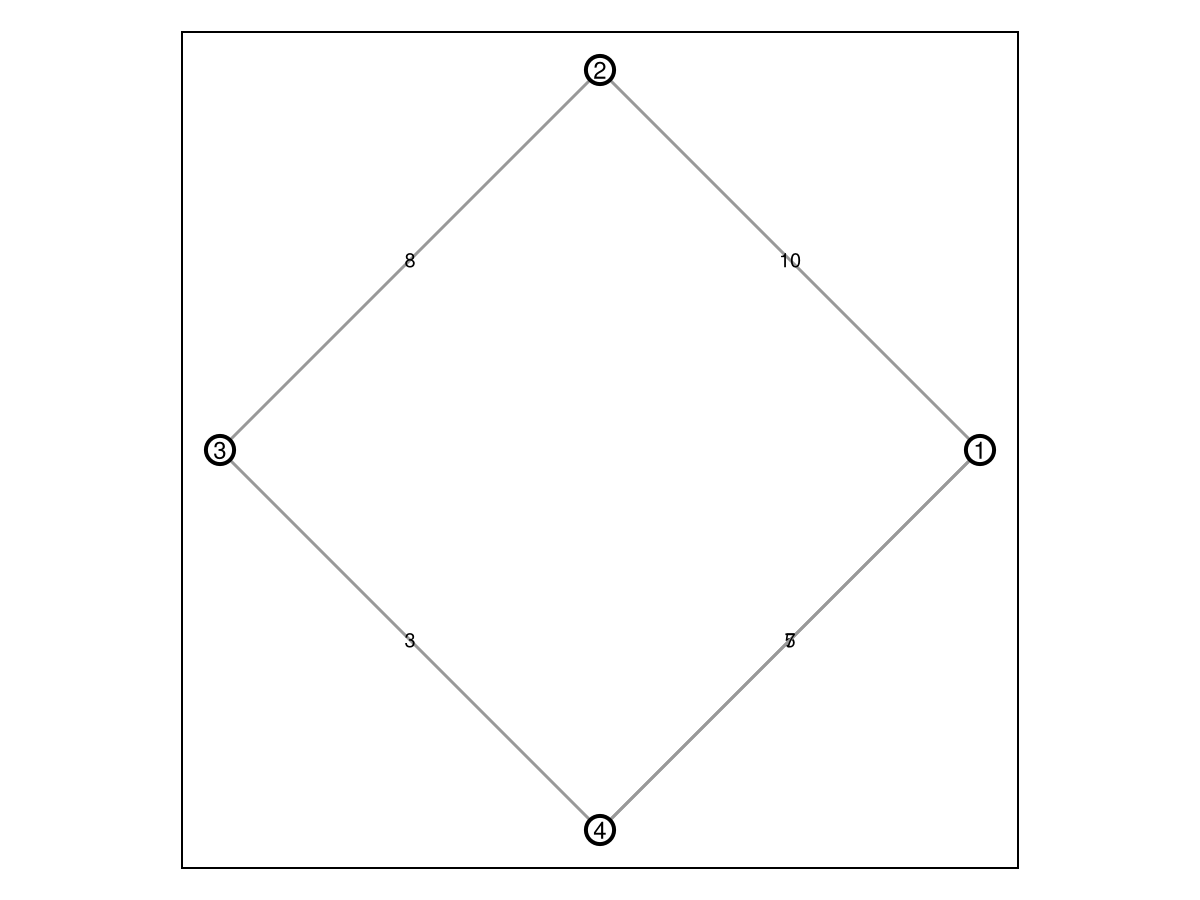

In [38]:
# Basic: 4-node directed network with default circular layout
C = [0 10 0 5; 0 0 8 0; 0 0 0 3; 7 0 0 0]
fig, xy = plotnetwork(C)
println("Node positions:")
display(xy)
dcf()

In [39]:
C

4×4 Matrix{Int64}:
 0  10  0  5
 0   0  8  0
 0   0  0  3
 7   0  0  0

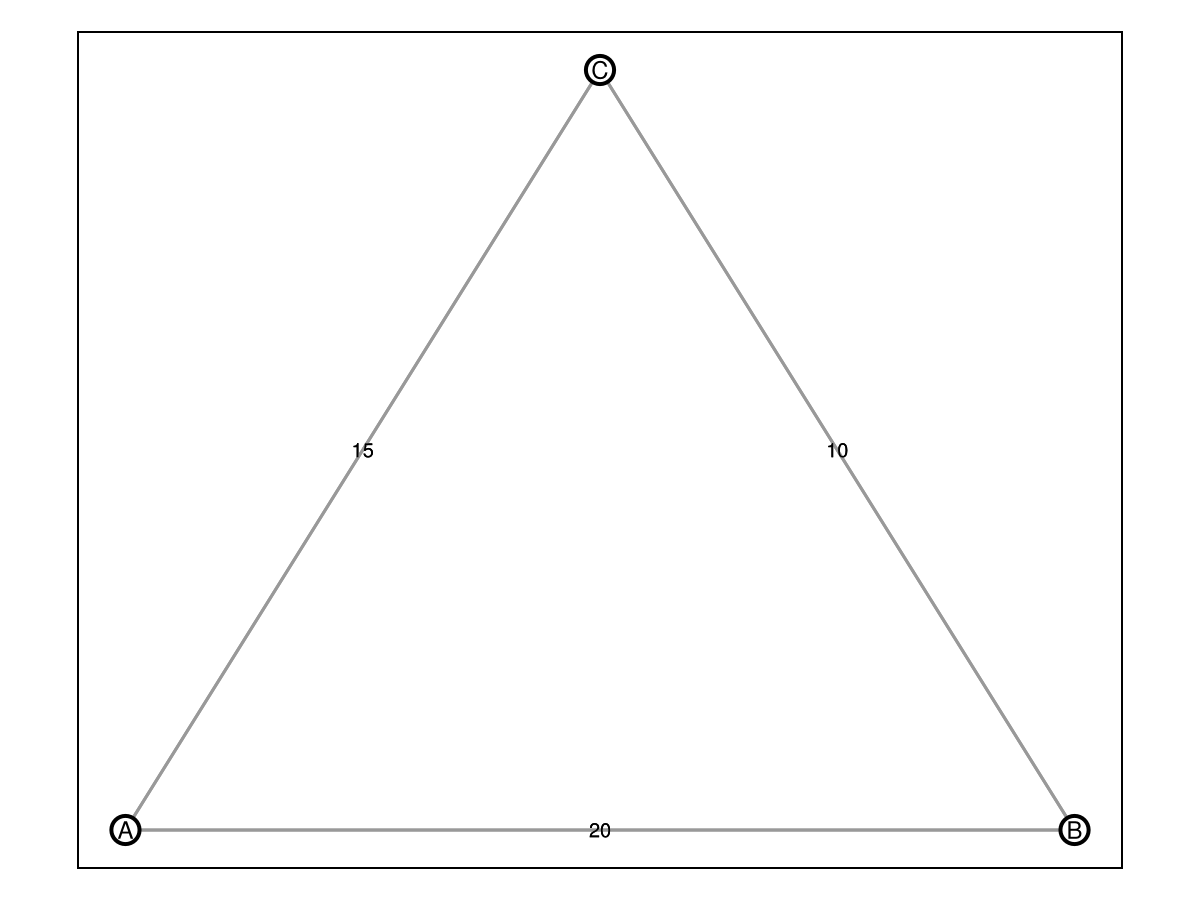

In [40]:
# Custom node positions and labels
C = [0 20 15; 20 0 10; 15 10 0]
xy_custom = [0.0 0.0; 1.0 0.0; 0.5 0.8]
fig, xy = plotnetwork(C; xy=xy_custom, labels=["A", "B", "C"])
dcf()


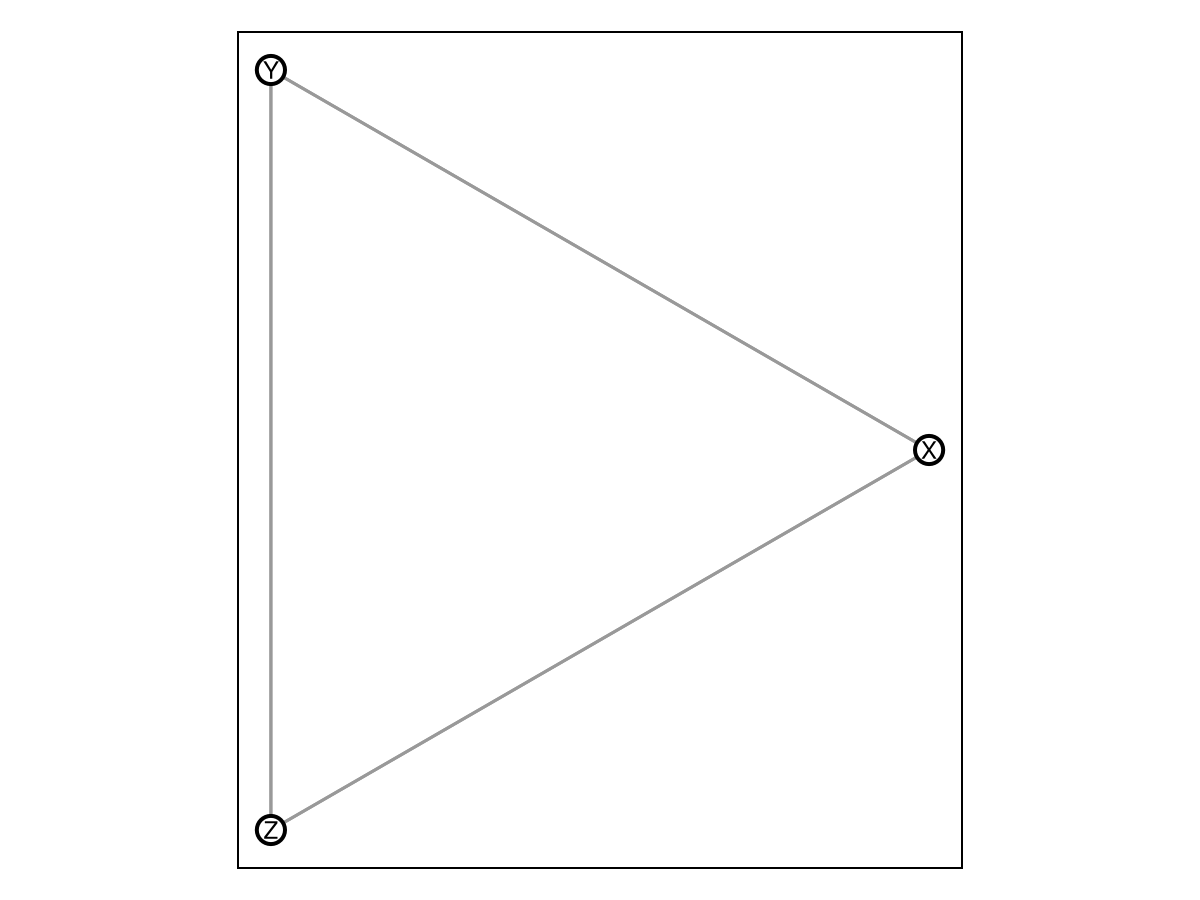

In [41]:
# Suppress edge weight labels
C = [0 5 3; 5 0 4; 3 4 0]
fig, xy = plotnetwork(C; weights=false, labels=["X", "Y", "Z"])
dcf()

Single node position: [1.0 0.0]


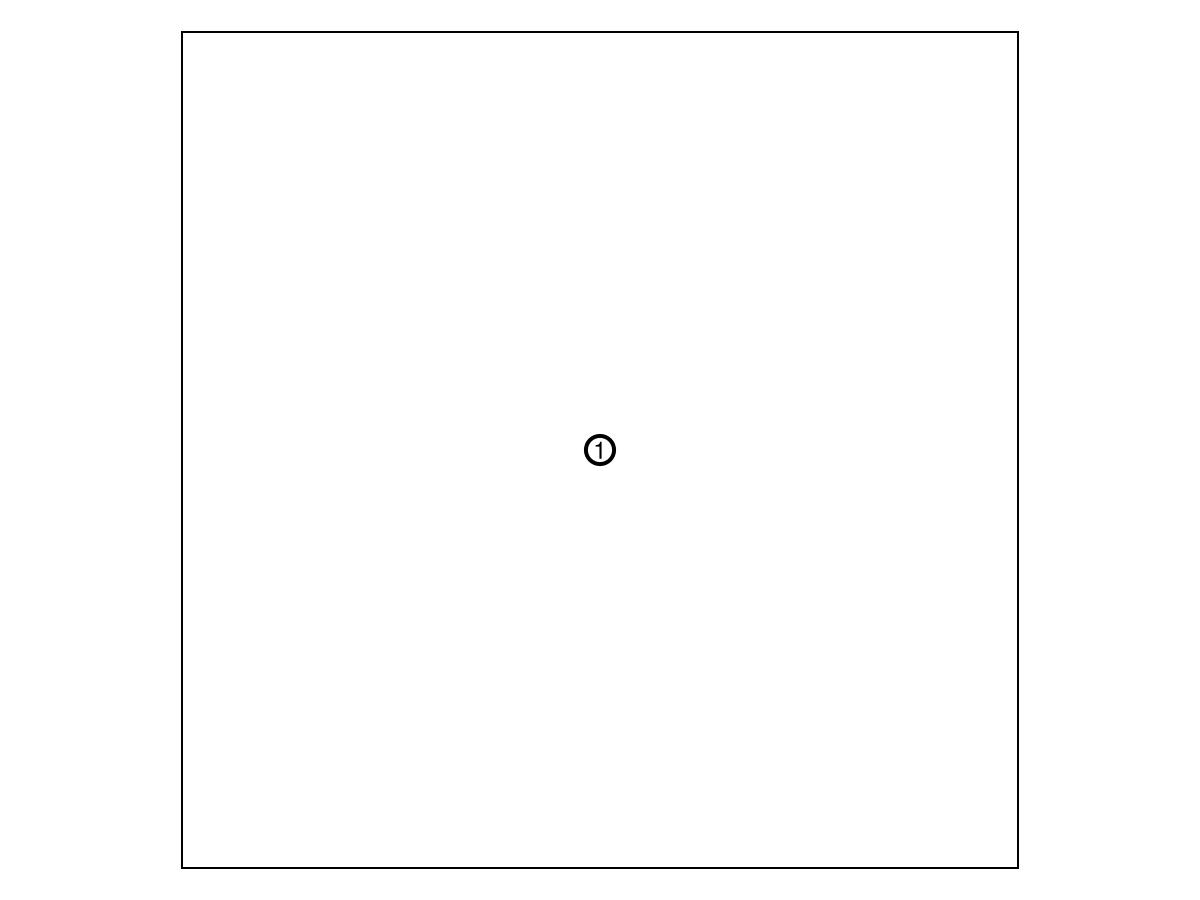

In [42]:
# Single node (edge case)
fig, xy = plotnetwork(reshape([0], 1, 1))
println("Single node position: ", xy)
dcf()

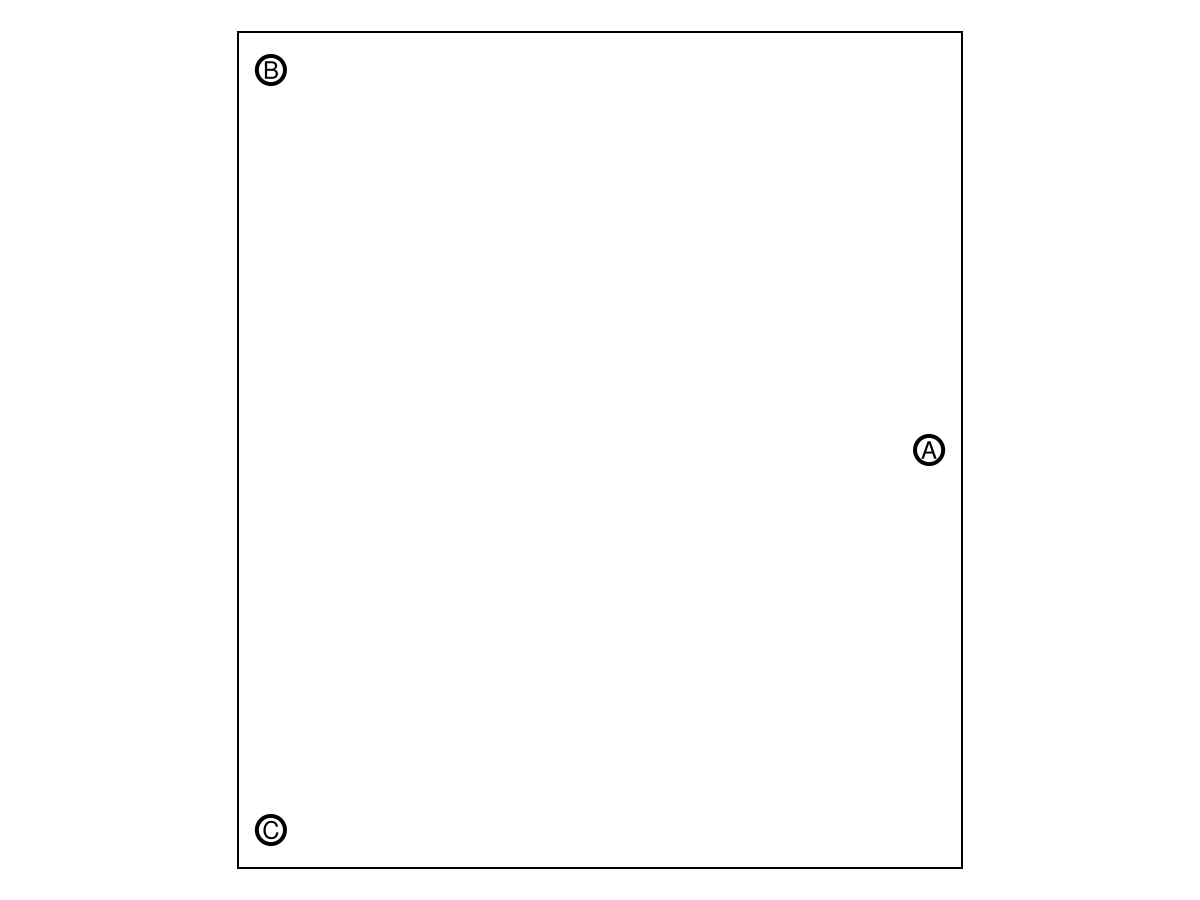

In [43]:
# All-zero matrix: nodes but no edges
fig, xy = plotnetwork(zeros(Int, 3, 3); labels=["A", "B", "C"])
dcf()

---
## Combined: Typical Workflow

Demonstrates helpers working together in a realistic scenario: solve a small network problem, post-process results, and display them.

In [44]:
# Transportation cost matrix: 3 warehouses × 4 customers
TC = [12.0 8.0 15.0 10.0;
      9.0  14.0  7.0 11.0;
      6.0  10.0 13.0  5.0]

wh = ["Atlanta", "Dallas", "Chicago"]
cust = ["NYC", "LA", "Miami", "Seattle"]

# Display the cost matrix
prt(TC; rows=wh, cols=cust, row_title="From \\ To")

 ─────────── ───── ──── ─────── ─────────
  From \\ To   NYC   LA   Miami   Seattle 
 ─────────── ───── ──── ─────── ─────────
    Atlanta    12    8      15        10
     Dallas     9   14       7        11
    Chicago     6   10      13         5
 ─────────── ───── ──── ─────── ─────────


In [45]:
# Simulate solver output with artifacts, then clean up
x_raw = [0.0, 0.9999999998, 1e-13, 0.0,
         1.0000000002, 0.0, 0.9999999997, 0.0,
         -1e-14, 0.0, 1e-15, 1.0000000001]

# Snap to clean binary values and reshape
X = snapvals(x_raw, 3, 4)
println("Cleaned assignment matrix:")
prt(X; rows=wh, cols=cust, row_title="From \\ To")

Cleaned assignment matrix:
 ─────────── ───── ──── ─────── ─────────
  From \\ To   NYC   LA   Miami   Seattle 
 ─────────── ───── ──── ─────── ─────────
    Atlanta     0    0       1         0
     Dallas     1    1       0         0
    Chicago     0    0       0         1
 ─────────── ───── ──── ─────── ─────────


In [46]:
# Extract active assignments
active = findall(isone, X)
println("Active assignments:")
for idx in active
    i, j = Tuple(idx)
    println("  $(wh[i]) → $(cust[j])  (cost: $(TC[i,j]))")
end
println("Total cost: ", sum(TC[idx] for idx in active))

Active assignments:
  Dallas → NYC  (cost: 9.0)
  Dallas → LA  (cost: 14.0)
  Atlanta → Miami  (cost: 15.0)
  Chicago → Seattle  (cost: 5.0)
Total cost: 43.0


In [47]:
# Convert to labeled DataFrame for export
df = mat2df(X, cust; rows=wh)
println("Assignment DataFrame:")
prt(df)

Assignment DataFrame:
 ───────── ───── ───── ─────── ─────────
            NYC    LA   Miami   Seattle 
 ───────── ───── ───── ─────── ─────────
  Atlanta   0.0   0.0     1.0       0.0
   Dallas   1.0   1.0     0.0       0.0
  Chicago   0.0   0.0     0.0       1.0
 ───────── ───── ───── ─────── ─────────


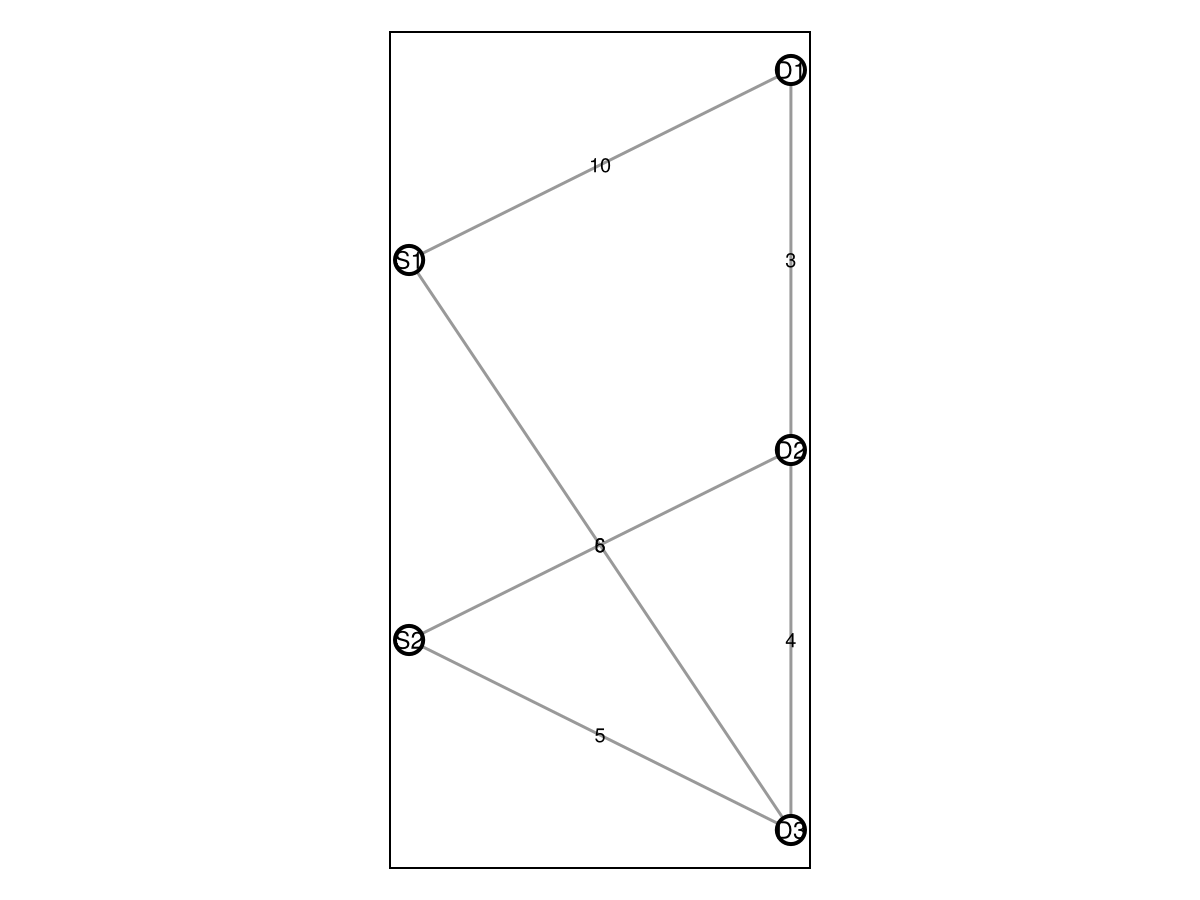

In [48]:
# Visualize a small supply network
# 5-node network: nodes 1-2 = supply, 3-5 = demand
C_net = [0 0 10 0 8;
         0 0  0 6 5;
         0 0  0 3 0;
         0 0  0 0 4;
         0 0  0 0 0]
xy_net = [0.0 1.0; 0.0 0.0; 1.0 1.5; 1.0 0.5; 1.0 -0.5]
fig, _ = plotnetwork(C_net; xy=xy_net, labels=["S1", "S2", "D1", "D2", "D3"])
dcf()


---
All cells executed without error — helper functions verified.